# Customer Churn Prediction - Final Model

This notebook refines the baseline Logistic Regression with:
- **Cross-validation** for reliable performance estimation
- **GridSearchCV** for hyperparameter tuning
- **Threshold optimization** based on business cost
- Final model export for deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score, recall_score, precision_score, 
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve
)

# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (5634, 29)
Test:  (1409, 29)


## 1. Cross-Validation

A single train/test split can be misleading - performance depends heavily on which 
specific samples ended up in the test set. Cross-validation evaluates the model on 
multiple splits, providing a more reliable estimate of how it will generalize.

We use **Stratified K-Fold** (k=5) to preserve class distribution in each fold.

In [2]:
# Baseline Logistic Regression
baseline = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate on multiple metrics
metrics_to_track = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}
for metric in metrics_to_track:
    scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
    cv_results[metric] = scores

# Display results
print("Cross-Validation Results (5-fold) - Logistic Regression Baseline")
print("=" * 65)
print(f"{'Metric':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 65)
for metric, scores in cv_results.items():
    print(f"{metric:<12} {scores.mean():>8.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}")

Cross-Validation Results (5-fold) - Logistic Regression Baseline
Metric           Mean      Std      Min      Max
-----------------------------------------------------------------
accuracy       0.7497   0.0149   0.7267   0.7666
precision      0.5185   0.0186   0.4901   0.5393
recall         0.8020   0.0366   0.7458   0.8528
f1             0.6296   0.0224   0.5915   0.6526
roc_auc        0.8461   0.0125   0.8255   0.8627


## 2. Hyperparameter Tuning with GridSearchCV

We tune the regularization strength (`C`) and penalty type (L1 vs L2) using 
grid search with cross-validation. The goal is to find the combination that 
maximizes ROC-AUC across folds.

- **C**: inverse of regularization strength. Small C = strong regularization (simpler model), large C = weak regularization (model fits training data more closely).
- **penalty**: L1 (Lasso, drives some weights to 0) or L2 (Ridge, shrinks all weights).

In [3]:
# Hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # supports both l1 and l2
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.8463


C:\Users\Fanto\Documents\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 3. Tuned Model - Test Set Performance

Train the tuned model on the full training set, then evaluate on the held-out test set.

In [4]:
# Train tuned model on full training data
best_model = grid_search.best_estimator_

# Predictions on test set
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

# Metrics
print("Tuned Logistic Regression — Test Set Performance:")
print("=" * 50)
print(f"  Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_tuned):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_tuned):.4f}")

Tuned Logistic Regression — Test Set Performance:
  Precision: 0.5052
  Recall:    0.7861
  F1:        0.6151
  ROC-AUC:   0.8412


## 4. Threshold Optimization

By default, classifiers predict class 1 when `predict_proba > 0.5`. But this 
default is arbitrary - different thresholds yield different precision/recall tradeoffs.

In churn prediction, the business cost is asymmetric:
- **False Negative (missed churner)**: ~1000 PLN (lost customer LTV)
- **False Positive (false alarm)**: ~15 PLN (unnecessary retention call)

We can find the threshold that maximizes business value, not just F1.

In [5]:
# Compute precision/recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_tuned)

# F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Find threshold that maximizes F1
best_f1_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_f1_idx]

print(f"Default threshold (0.50):")
print(f"  F1: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print()
print(f"Best F1 threshold ({best_threshold_f1:.3f}):")
print(f"  F1: {f1_scores[best_f1_idx]:.4f}")
print(f"  Precision: {precisions[best_f1_idx]:.4f}")
print(f"  Recall: {recalls[best_f1_idx]:.4f}")

Default threshold (0.50):
  F1: 0.6151
  Precision: 0.5052
  Recall: 0.7861

Best F1 threshold (0.574):
  F1: 0.6236
  Precision: 0.5413
  Recall: 0.7353


## 5. Business-Driven Threshold

F1 treats precision and recall equally, but churn has asymmetric costs. We optimize 
the threshold to maximize **business value**:

- Saving a churner = +1000 PLN
- Cost of retention call = -15 PLN

Expected business value at threshold T:

value(T) = TP × 1000 - FP × 15 - FN × 1000

(We don't penalize TN — keeping a loyal customer who would stay anyway costs nothing.)

In [6]:
# Business cost parameters
COST_SAVED_CHURNER = 1000   # Value of retaining a customer
COST_FALSE_ALARM = 15        # Cost of unnecessary retention call
COST_MISSED_CHURNER = 1000   # Lost customer revenue

# Compute business value at each threshold
business_values = []
threshold_grid = np.arange(0.05, 0.95, 0.01)

for t in threshold_grid:
    y_pred_t = (y_proba_tuned >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    value = (tp * COST_SAVED_CHURNER) - (fp * COST_FALSE_ALARM) - (fn * COST_MISSED_CHURNER)
    business_values.append(value)

business_values = np.array(business_values)
best_business_idx = np.argmax(business_values)
best_business_threshold = threshold_grid[best_business_idx]

# Evaluate at business-optimal threshold
y_pred_business = (y_proba_tuned >= best_business_threshold).astype(int)

print(f"Business-optimal threshold: {best_business_threshold:.3f}")
print(f"Expected business value: {business_values[best_business_idx]:,.0f} PLN")
print()
print(f"  Precision: {precision_score(y_test, y_pred_business):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_business):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_business):.4f}")

Business-optimal threshold: 0.070
Expected business value: 358,180 PLN

  Precision: 0.3207
  Recall:    0.9947
  F1:        0.4850


## 6. Threshold Analysis Visualization

Plot precision, recall, F1, and business value across all thresholds to visualize 
the tradeoffs and confirm our chosen threshold.

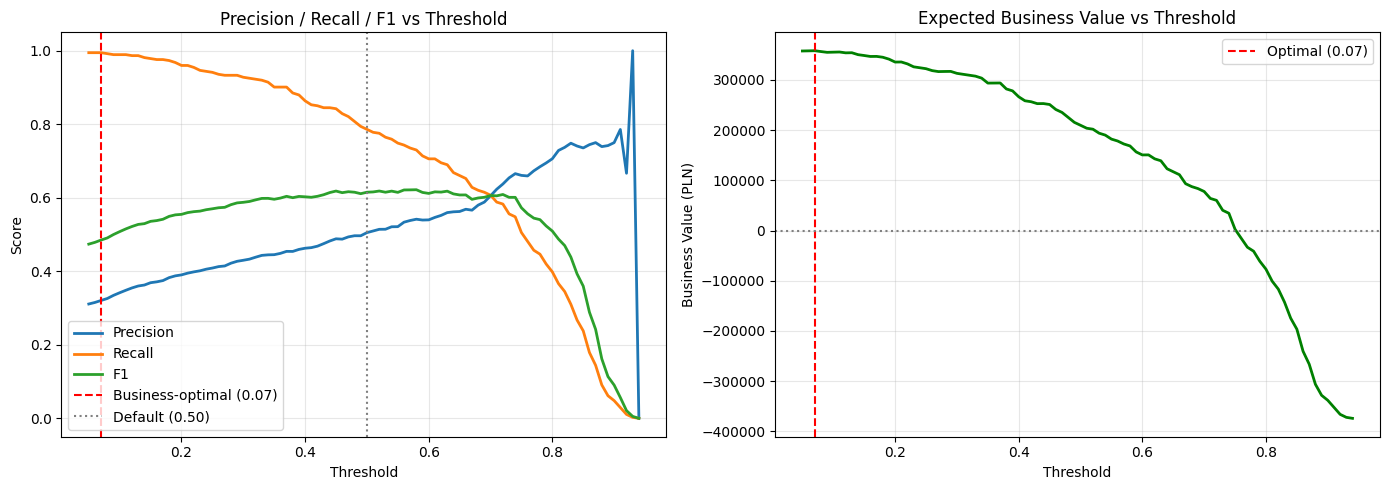

In [7]:
# Recompute metrics across threshold grid for plotting
prec_grid = []
rec_grid = []
f1_grid = []

for t in threshold_grid:
    y_pred_t = (y_proba_tuned >= t).astype(int)
    prec_grid.append(precision_score(y_test, y_pred_t, zero_division=0))
    rec_grid.append(recall_score(y_test, y_pred_t))
    f1_grid.append(f1_score(y_test, y_pred_t, zero_division=0))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: precision/recall/F1 vs threshold
ax1.plot(threshold_grid, prec_grid, label='Precision', linewidth=2)
ax1.plot(threshold_grid, rec_grid, label='Recall', linewidth=2)
ax1.plot(threshold_grid, f1_grid, label='F1', linewidth=2)
ax1.axvline(best_business_threshold, color='red', linestyle='--', label=f'Business-optimal ({best_business_threshold:.2f})')
ax1.axvline(0.5, color='gray', linestyle=':', label='Default (0.50)')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision / Recall / F1 vs Threshold')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: business value vs threshold
ax2.plot(threshold_grid, business_values, color='green', linewidth=2)
ax2.axvline(best_business_threshold, color='red', linestyle='--', label=f'Optimal ({best_business_threshold:.2f})')
ax2.axhline(0, color='gray', linestyle=':')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Business Value (PLN)')
ax2.set_title('Expected Business Value vs Threshold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save Final Model

Save the trained model and the business-optimal threshold so they can be loaded 
for inference without retraining.

In [8]:
import os

# Create models folder
os.makedirs('../models', exist_ok=True)

# Save model + threshold together as a dict
model_artifact = {
    'model': best_model,
    'threshold': best_business_threshold,
    'feature_names': X_train.columns.tolist(),
    'metrics_test': {
        'precision': precision_score(y_test, y_pred_business),
        'recall': recall_score(y_test, y_pred_business),
        'f1': f1_score(y_test, y_pred_business),
        'roc_auc': roc_auc_score(y_test, y_proba_tuned),
        'business_value_pln': int(business_values[best_business_idx])
    }
}

joblib.dump(model_artifact, '../models/churn_model.joblib')

print("Model saved to: ../models/churn_model.joblib")
print(f"\nFinal model summary:")
print(f"  Threshold:      {model_artifact['threshold']:.3f}")
print(f"  Test recall:    {model_artifact['metrics_test']['recall']:.4f}")
print(f"  Test precision: {model_artifact['metrics_test']['precision']:.4f}")
print(f"  Test ROC-AUC:   {model_artifact['metrics_test']['roc_auc']:.4f}")
print(f"  Business value: {model_artifact['metrics_test']['business_value_pln']:,} PLN")

Model saved to: ../models/churn_model.joblib

Final model summary:
  Threshold:      0.070
  Test recall:    0.9947
  Test precision: 0.3207
  Test ROC-AUC:   0.8412
  Business value: 358,180 PLN


## Summary

**Final Model:** Logistic Regression (C=10, L2 regularization)
- Trained on 5634 samples with stratified 5-fold CV
- Hyperparameters tuned via GridSearchCV (ROC-AUC scoring)
- Threshold optimized for business value (0.07)

**Test Set Performance:**
- Recall: 99.5% - catches nearly all churners
- Precision: 32.1% - many false alarms (acceptable given cost structure)
- ROC-AUC: 0.841 - strong class separation
- Expected business value: 358,180 PLN on test set

**Production deployment:**
The model and threshold are saved together in `models/churn_model.joblib` 
and can be loaded with `joblib.load()` for inference.

**Next steps:**
- A/B test in production against current retention process
- Monitor model drift over time
- Retrain quarterly with fresh data
- Refine cost parameters with business stakeholders